
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [1]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv')
medical_df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. Я би візуалізувала залежності charges від кожної змінної, щоб зрозуміти, що впливає на charges і які саме ці залежності
2. Відкинула б колонки, які не впливають на charges, орієнтувалась би по вагомих колонках. Один із варіантів - використала б візуальні зображення, побудовані в пункті 1, щоб орієнтовно побудувати графіки для кожної колонки. На основі цих графіків для кожної колонки зробити передбачення charges, а потім взяти середнє арифметичне цих передбачень
3. Попередній пункт можна розширити додаючи ваги до кожної колонки, наприклад побудувавши кореляційну матрицю, і ці ваги враховувала б при обчисленні середнього арифметичного, зробивши його "зваженим"

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [2]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

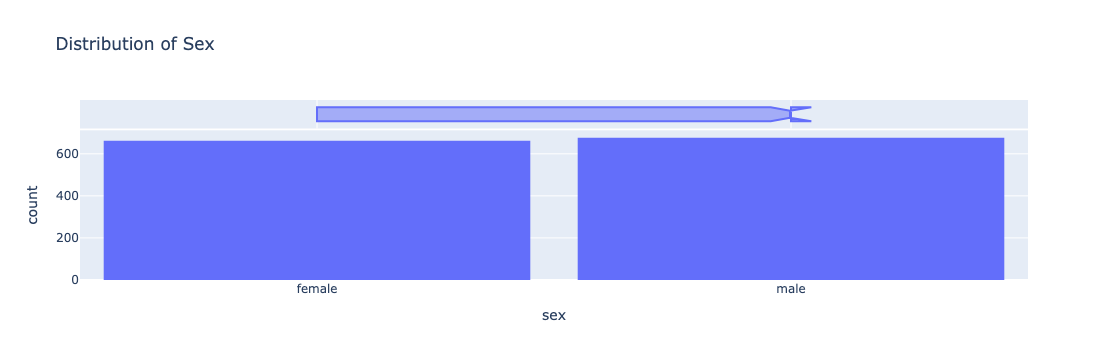

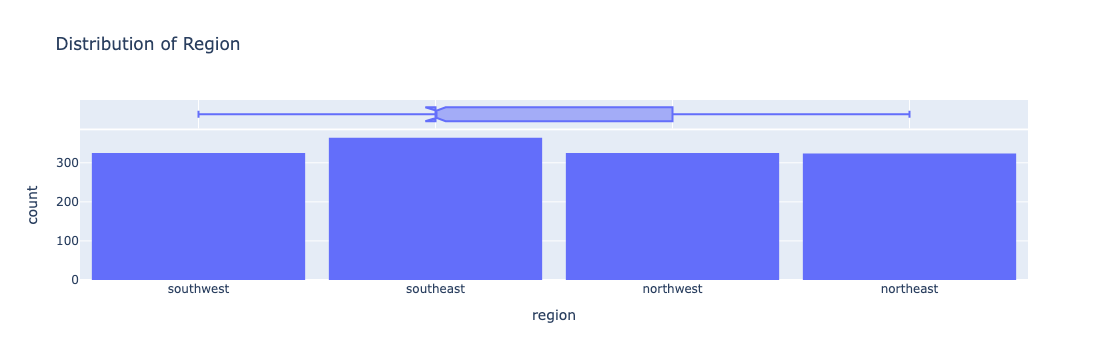

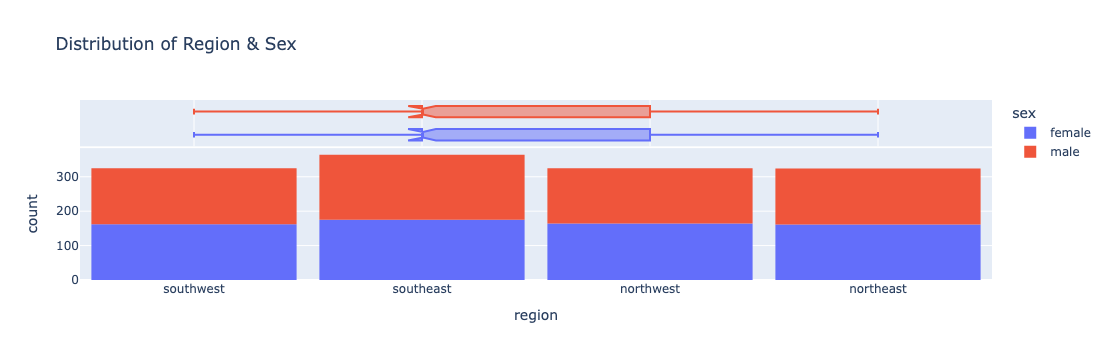

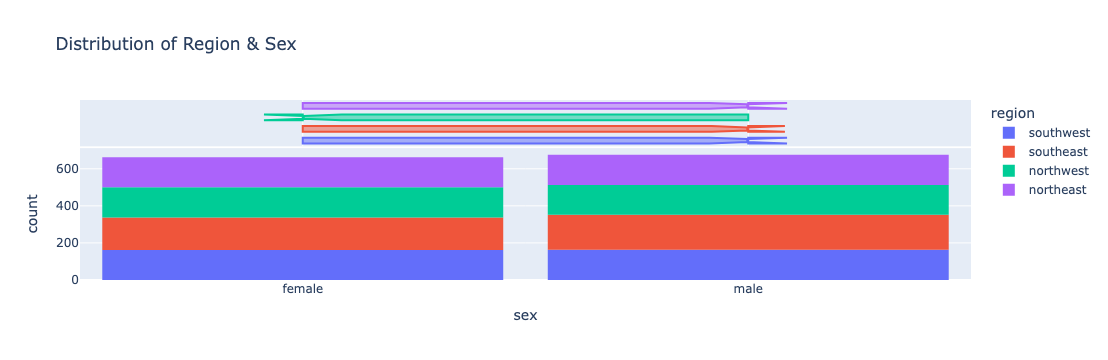

In [3]:
fig = px.histogram(medical_df,
                   x='sex',
                   marginal='box',
                   title='Distribution of Sex')
fig.update_layout(bargap=0.1)
fig.show()

fig = px.histogram(medical_df,
                   x='region',
                   marginal='box',
                   title='Distribution of Region')
fig.update_layout(bargap=0.1)
fig.show()

# також спробувала відобразити на одному графіку дві колонки
fig = px.histogram(medical_df,
                   x='region',
                   color='sex',
                   marginal='box',
                   title='Distribution of Region & Sex')
fig.update_layout(bargap=0.1)
fig.show()

fig = px.histogram(medical_df,
                   x='sex',
                   color='region',
                   marginal='box',
                   title='Distribution of Region & Sex')
fig.update_layout(bargap=0.1)
fig.show()

Спостереження: дані розподілені рівномірно відсноно обох категорій - статі та регіону.
Скоріш за все, дані підібрані так спеціально, тому що навіть візуалізувавши ці категорії попарно, бачимо що між собою вони теж рівномірно розподілені (кожен регіон місить близько 50% жінок, 50% чоловіків, одидві статі включать в себе по 25% клієнтів з кожного регіону)

Висновок: я вважаю що згідно наявних даних ці категорії в кінцевому випадку не впливатимуть на результат і ми їх до уваги не братимемо. Але це поки лише припущення :)

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

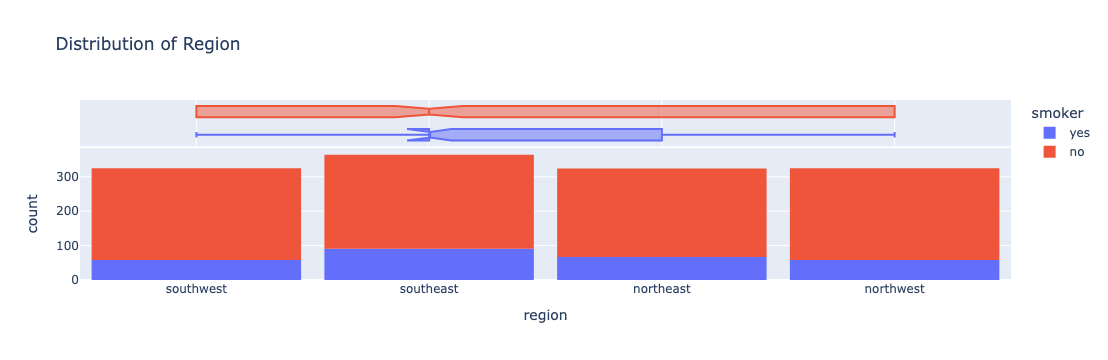

In [4]:
fig = px.histogram(medical_df,
                   x='region',
                   color='smoker',
                   marginal='box',
                   title='Distribution of Region')
fig.update_layout(bargap=0.1)
fig.show()

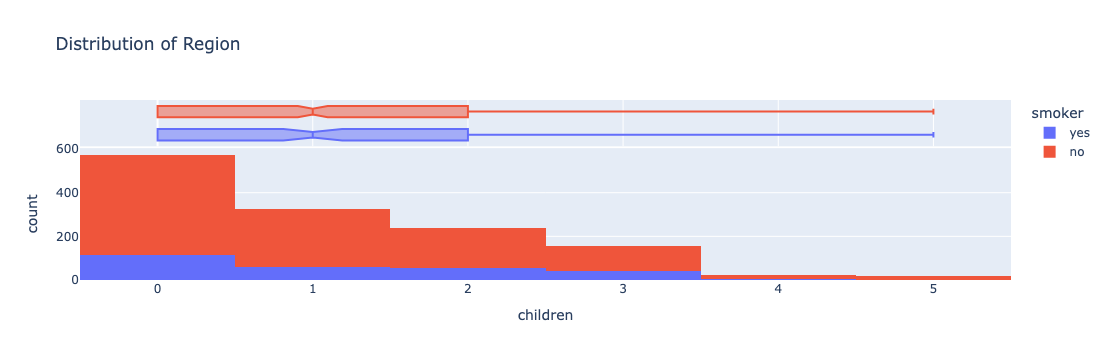

In [5]:
fig = px.histogram(medical_df,
                   x='children',
                   color='smoker',
                   marginal='box',
                   title='Distribution of Region')
fig.show()

In [6]:
115/459, 61/263, 55/185, 39/118

(0.25054466230936817,
 0.23193916349809887,
 0.2972972972972973,
 0.3305084745762712)

Немає кореляції між регіоном та тим, що клієнт курець, аналонічно між кількістю дітей та тим, що клієнт курець.
З першого графіку видно, що по регіонах співвідношення курців до некурців плюс мінус однакове.
На другому графіку мені було важко оцінити візуально, але порахувавши пропорції виглядає, що процент курців серед клієнтів з різною кількістю дітей становить 23-33%, я вважаю що це теж плюс мінус однаково, явної закономірності немає

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

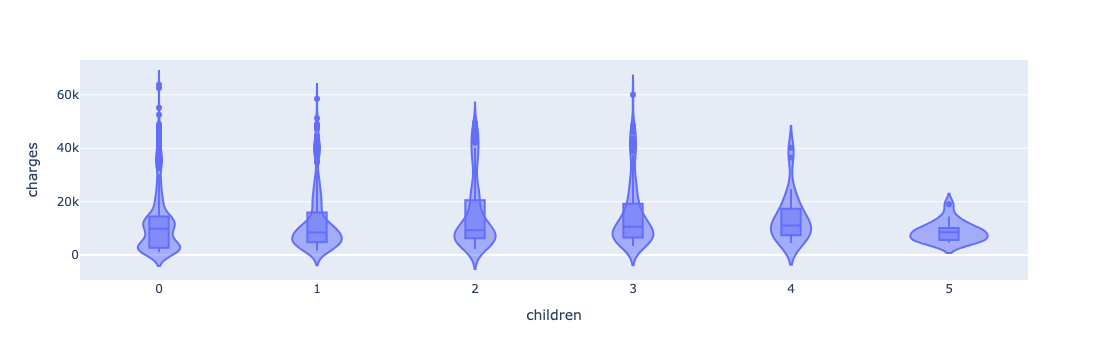

In [7]:
fig = px.violin(medical_df,
                y="charges",
                x="children",
                box=True,
                hover_data=medical_df.columns)
fig.show()

Важко побачити якусь сильну залежність, є багато викидів, особливо в найчисельніших групах. Здається візуально (і за значенням медіани), що зі збільшенням кількості дітей трохи зростає середня сума зборів, але ці зміни не є суттєвими.
Припускаю, що кількість дітей не впливає істотно на charges

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [8]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [9]:
def estimate_charges(age, w, b):
    return w * age + b

In [10]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

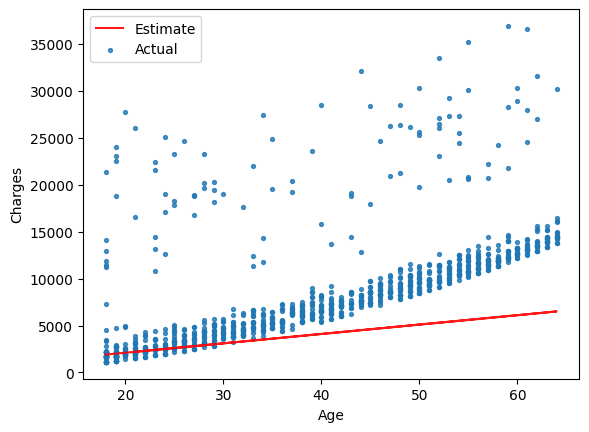

In [11]:
try_parameters(non_smoker_df, 100, 100)

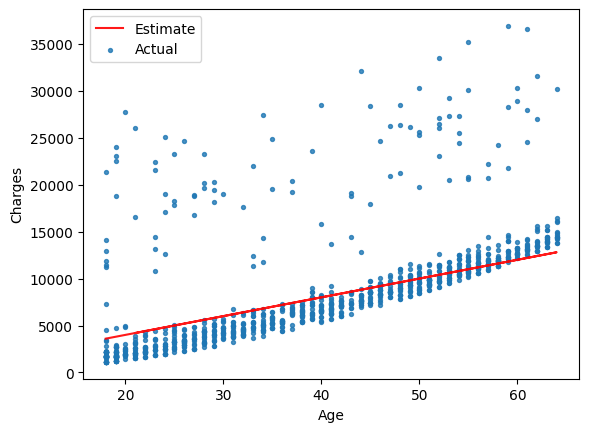

In [12]:
try_parameters(non_smoker_df, 200, 0)

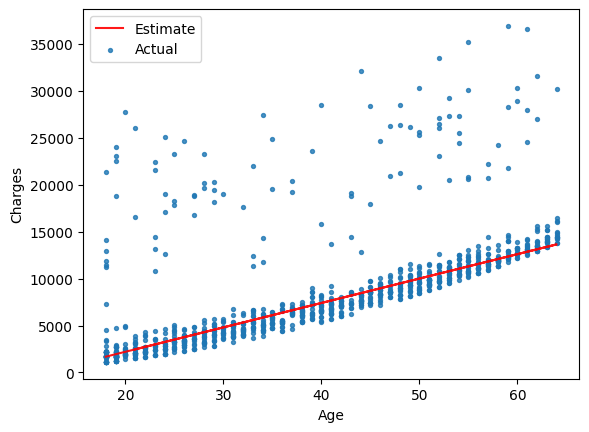

In [13]:
try_parameters(non_smoker_df, 260, -3000)

Перший крок - написала рандомні цифри, щоб зрозуміти як виглядатиме лінія
Другий крок - почала коригувати в потрібну сторону (трохи збільшити кут і підняти лінію)
Третій крок - далі продовжуємо "підкручувати"
Четвертий крок - я розумію, що орієнтувалась на дані без викидів, але викиди теж треба враховувати, тож трохи піднімаю лінію

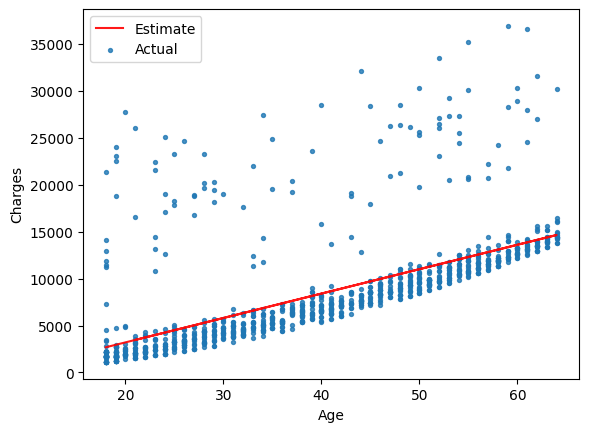

In [14]:
try_parameters(non_smoker_df, 260, -2000)

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [15]:
import numpy as np
def RMSE(df, w, b):
    diff = df.charges - estimate_charges(df.age, w, b)
    return np.sqrt(sum(diff ** 2)/len(df))

RMSE(non_smoker_df, 100, 100), RMSE(non_smoker_df, 200, 0), RMSE(non_smoker_df, 260, -2000), RMSE(non_smoker_df, 270, -2000)
        

(np.float64(6826.734303208685),
 np.float64(4790.154131157635),
 np.float64(4667.658904656395),
 np.float64(4666.94429339693))

Перебираючи різні варіанти, найнижче значення втрат, якого мені вдалось досягти - це ~4667. Як виявилось, візуальні припущення, зроблені "на око", виявились найкращими, бо коригувавши далі, нічого кращого не виходило.
Стратегія, яка намальовується - визначити розумні інтервали для w i b, розбити їх на linspace і в циклі перераховувати rsme для кожної комбінації, а потім знайти серед них мінімальну. Виглядає це дуже ресурсозатратним